### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np

def generate_data_points(
    N,
    epsilon,
    p,
    cov0=None,
    cov1=None,
    mean0=None,
    mean1=None,
    random_state=None
):
    rng = np.random.default_rng(random_state)

    if mean0 is None:
        mean0 = np.array([0.0, 0.0])
    else:
        mean0 = np.array(mean0)

    if mean1 is None:
        mean1 = np.array([epsilon, 0.0])
    else:
        mean1 = np.array(mean1)

    if cov0 is None:
        cov0 = np.array([[0.5, 0.0],
                         [0.0, 0.5]])
    else:
        cov0 = np.array(cov0)

    if cov1 is None:
        cov1 = np.array([[0.4, 0.0],
                         [0.0, 0.4]])
    else:
        cov1 = np.array(cov1)

    y = (rng.random(N) < p).astype(int)
    X = np.zeros((N, 2))

    n0 = np.sum(y == 0)
    n1 = np.sum(y == 1)

    if n0 > 0:
        X[y == 0] = rng.multivariate_normal(mean0, cov0, size=n0)
    if n1 > 0:
        X[y == 1] = rng.multivariate_normal(mean1, cov1, size=n1)

    return X, y

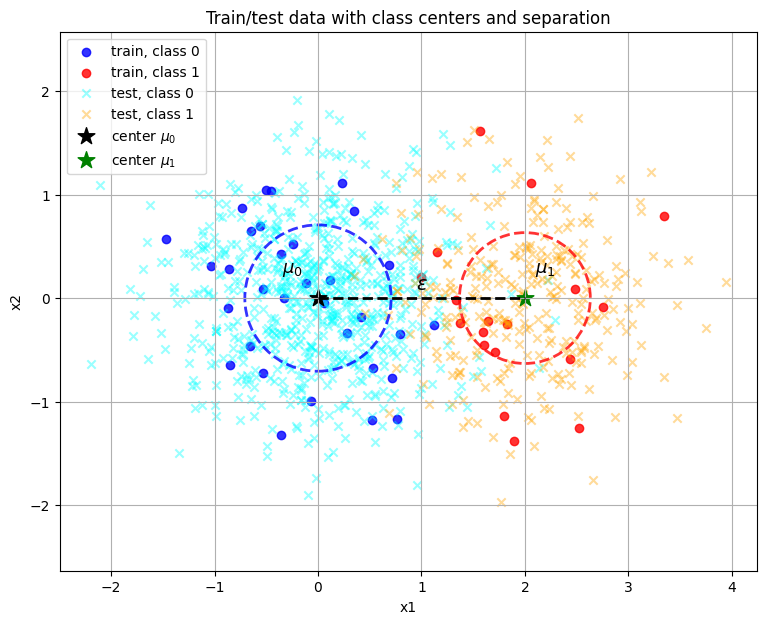

In [2]:
# Parameters
epsilon = 2
p = 0.3

# Generate data
X_train, y_train = generate_data_points(50, epsilon, p)
X_test, y_test = generate_data_points(1000, epsilon, p)

# Means
mean0 = np.array([0.0, 0.0])
mean1 = np.array([epsilon, 0.0])

# Standard deviation radii for contour circles
r0 = np.sqrt(0.5)
r1 = np.sqrt(0.4)

fig, ax = plt.subplots(figsize=(9, 7))

# Data points
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
           marker='o', color='blue', label='train, class 0', alpha=0.8)

ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           marker='o', color='red', label='train, class 1', alpha=0.8)

ax.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1],
           marker='x', color='cyan', label='test, class 0', alpha=0.4)

ax.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
           marker='x', color='orange', label='test, class 1', alpha=0.4)

# Plot class centers
ax.scatter(mean0[0], mean0[1], color='black', s=160, marker='*', label=r'center $\mu_0$')
ax.scatter(mean1[0], mean1[1], color='green', s=160, marker='*', label=r'center $\mu_1$')

# Dashed line representing epsilon
ax.plot([mean0[0], mean1[0]], [mean0[1], mean1[1]], 'k--', linewidth=2)
ax.text(epsilon / 2, 0.08, r'$\varepsilon$', fontsize=14, ha='center')

# Circles representing Gaussian spread as the Covariance matrix is a diagonal
circle0 = plt.Circle(mean0, r0, color='blue', fill=False, linestyle='--', linewidth=2, alpha=0.8)
circle1 = plt.Circle(mean1, r1, color='red', fill=False, linestyle='--', linewidth=2, alpha=0.8)

ax.add_patch(circle0)
ax.add_patch(circle1)

# Labels
ax.annotate(r'$\mu_0$', xy=mean0, xytext=(-0.35, 0.25), fontsize=13)
ax.annotate(r'$\mu_1$', xy=mean1, xytext=(epsilon + 0.1, 0.25), fontsize=13)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Train/test data with class centers and separation")
ax.legend()
ax.grid(True)
ax.axis('equal')
plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

The Bayes optimal classifier assigns a point $ x \in \mathbb{R}^2 $ to the class with the highest posterior probability:

$$
g(x)=
\begin{cases}
1 & \text{if } \mathbb{P}(Y=1 \mid X=x) \ge \mathbb{P}(Y=0 \mid X=x), \\
0 & \text{otherwise.}
\end{cases}
$$

Using Bayes' rule, this is equivalent to:

$$
g(x)=1
\iff
p\,f_1(x) \ge (1-p)\,f_0(x),
$$

where:
- $ p = \mathbb{P}(Y=1) $,
- $ f_0(x) $ is the density of $ X $ at $ x $ given $ Y=0 $,
- $ f_1(x) $ is the density of $ X $ at $ x $ given $ Y=1 $.

We are given:

$$
X \mid Y=0 \sim \mathcal{N}(\mu_0, \Sigma_0), \quad
X \mid Y=1 \sim \mathcal{N}(\mu_1, \Sigma_1),
$$

with:

$$
\mu_0 =
\begin{pmatrix}
0 \\
0
\end{pmatrix}, \quad
\mu_1 =
\begin{pmatrix}
\varepsilon \\
0
\end{pmatrix},
$$

and:

$$
\Sigma_0 = 0.5\,I, \quad
\Sigma_1 = 0.4\,I.
$$


The density of a multivariate Gaussian is:

$$
f_k(x) =
\frac{1}{2\pi \, \det(\Sigma_k)^{1/2}}
\exp\left(
-\frac{1}{2}(x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k)
\right).
$$

We compute:

$$
\det(\Sigma_0)^{1/2} = 0.5, \quad
\det(\Sigma_1)^{1/2} = 0.4,
$$

$$
\Sigma_0^{-1} = 2I, \quad
\Sigma_1^{-1} = 2.5I.
$$


Taking the logarithm of the likelihood ratio:

$$
g(x)=1
\iff
\log\frac{p}{1-p}
+ \log\frac{\det(\Sigma_0)^{1/2}}{\det(\Sigma_1)^{1/2}}
- \frac{1}{2}
\left[
(x-\mu_1)^T\Sigma_1^{-1}(x-\mu_1)
-
(x-\mu_0)^T\Sigma_0^{-1}(x-\mu_0)
\right]
\ge 0.
$$

Since:

$$
\frac{\det(\Sigma_0)^{1/2}}{\det(\Sigma_1)^{1/2}} = \frac{0.5}{0.4} = 1.25,
$$

we obtain:

$$
g(x)=1
\iff
\log\frac{1.25\,p}{1-p}
-\frac{1}{2}
\left[
2.5\|x-\mu_1\|^2 - 2\|x\|^2
\right]
\ge 0.
$$


Let $ x = (x_1, x_2) $. Then:

$$
\|x-\mu_1\|^2 = (x_1 - \varepsilon)^2 + x_2^2, \quad
\|x\|^2 = x_1^2 + x_2^2.
$$

After expansion, the classifier becomes:

$$
g(x)=1
\iff
-\frac{1}{4}(x_1^2 + x_2^2)
+ \frac{5}{2}\varepsilon x_1
- \frac{5}{4}\varepsilon^2
+ \log\frac{1.25\,p}{1-p}
\ge 0.
$$



**Decision boundary**

The decision boundary is obtained when equality holds:

$$
-\frac{1}{4}(x_1^2 + x_2^2)
+ \frac{5}{2}\varepsilon x_1
- \frac{5}{4}\varepsilon^2
+ \log\frac{1.25\,p}{1-p}
= 0.
$$

Multiplying by $-4$, we get:

$$
x_1^2 + x_2^2
- 10\varepsilon x_1
+ 5\varepsilon^2
- 4\log\frac{1.25\,p}{1-p}
= 0.
$$



**Interpretation**

- The decision boundary is **quadratic** (not linear).
- This is due to the fact that the covariance matrices are **different**.
- The boundary is actually a **circle** in this case.


**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

In [3]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
from scipy.stats import multivariate_normal

class BayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, epsilon=2.0, p=0.3):
        self.epsilon = epsilon
        self.p = p

    def fit(self, X, y=None):
        self.mean0_ = np.array([0.0, 0.0])
        self.mean1_ = np.array([self.epsilon, 0.0])

        self.cov0_ = np.array([[0.5, 0.0],
                               [0.0, 0.5]])

        self.cov1_ = np.array([[0.4, 0.0],
                               [0.0, 0.4]])

        self.prior0_ = 1.0 - self.p
        self.prior1_ = self.p

        return self

    def predict_proba(self, X):
        f0 = multivariate_normal.pdf(X, mean=self.mean0_, cov=self.cov0_)
        f1 = multivariate_normal.pdf(X, mean=self.mean1_, cov=self.cov1_)

        score0 = self.prior0_ * f0
        score1 = self.prior1_ * f1

        normalizer = score0 + score1

        proba0 = score0 / normalizer
        proba1 = score1 / normalizer

        return np.column_stack([proba0, proba1])

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)



In [4]:
epsilon = 2
p = 0.3

X_test, y_test = generate_data_points(10000, epsilon=epsilon, p=p, random_state=42)

bayes_clf = BayesClassifier(epsilon=epsilon, p=p)
bayes_clf.fit(X_test, y_test)   # fit does not really learn, it just sets parameters

y_pred = bayes_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

print(f"Bayes accuracy: {accuracy:.4f}")
print(f"Bayes error rate: {error_rate:.4f}")

Bayes accuracy: 0.9339
Bayes error rate: 0.0661


The Bayes classifier achieves an accuracy of about $93.39\%$, corresponding to an error rate of about $6.61\%$. This confirms that the classification problem is relatively easy for $\varepsilon = 2$, since the two classes are reasonably separated. However, the error is not zero because the Gaussian distributions overlap, which implies that some observations are inherently ambiguous.

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

From the model, we know that:

$$
X \mid Y=0 \sim \mathcal{N}(\mu_0, \Sigma_0), \quad
X \mid Y=1 \sim \mathcal{N}(\mu_1, \Sigma_1)
$$

where:

- each class follows a **Gaussian distribution**
- the covariance matrices are **different**:
  $$
  \Sigma_0 \neq \Sigma_1
  $$


### Analysis of different classifiers

#### 1. Linear Discriminant Analysis (LDA)

- Assumes Gaussian class-conditional distributions
- Assumes **shared covariance matrix**:
  $$
  \Sigma_0 = \Sigma_1
  $$
- Leads to a **linear decision boundary**

However In our case:
- this assumption is **violated**
- so LDA is **not optimal**


#### 2. Quadratic Discriminant Analysis (QDA)

- Assumes Gaussian class-conditional distributions
- Allows **different covariance matrices**:
  $$
  \Sigma_0 \neq \Sigma_1
  $$
- Leads to a **quadratic decision boundary**


#### 3. Other classifiers (e.g., logistic regression)

- Do not explicitly model the Gaussian structure
- Implicitly assume a **linear decision boundary**
- Therefore cannot capture the true optimal boundary here


### Conclusion

The data is generated from two Gaussian distributions with different covariance matrices. Therefore, the Bayes optimal classifier has a **quadratic decision boundary**.

Among the classifiers studied in the lectures, **QDA is the most adequate**, since its assumptions perfectly match the data-generating process.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

# Generate data (make sure it's 50 train as specified)
X_train, y_train = generate_data_points(50, epsilon=2, p=0.3, random_state=0)
X_test, y_test = generate_data_points(10_000, epsilon=2, p=0.3, random_state=1)

# Models
lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()
logreg = LogisticRegression()

# Train
lda.fit(X_train, y_train)
qda.fit(X_train, y_train)
logreg.fit(X_train, y_train)

# Predict
y_pred_lda = lda.predict(X_test)
y_pred_qda = qda.predict(X_test)
y_pred_log = logreg.predict(X_test)

# Errors
err_lda = 1 - accuracy_score(y_test, y_pred_lda)
err_qda = 1 - accuracy_score(y_test, y_pred_qda)
err_log = 1 - accuracy_score(y_test, y_pred_log)

print(f"LDA error: {err_lda:.4f}")
print(f"QDA error: {err_qda:.4f}")
print(f"Logistic Regression error: {err_log:.4f}")

LDA error: 0.0624
QDA error: 0.0729
Logistic Regression error: 0.0663


The fact that LDA achieves a lower error than the estimated Bayes error is due to statistical fluctuations. The Bayes error estimate is itself computed from a finite test sample, and thus subject to randomness.
Although QDA is theoretically the most appropriate model, the empirical results show that LDA achieves a lower test error than QDA.

This can be explained by the small size of the training set. QDA requires estimating separate covariance matrices for each class, which leads to higher variance in parameter estimation. With limited data, this results in poorer generalization.

In contrast, LDA makes stronger assumptions (shared covariance matrix), which reduces variance and can improve performance in small-sample regimes.
The good performance of LDA can also be explained by the fact that the covariance matrices of the two classes are very similar:

$$
\Sigma_0 = 0.5 I, \quad \Sigma_1 = 0.4 I.
$$

Although LDA assumes equal covariance matrices, this assumption is only mildly violated in this setting. As a result, the true decision boundary is close to linear, making LDA a good approximation of the Bayes classifier.

Combined with the smaller variance of LDA compared to QDA, this explains why LDA performs particularly well in this experiment.
As the number of training samples increases, we expect QDA to outperform LDA and approach the Bayes error, while LDA and logistic regression will remain suboptimal due to model bias.

In [8]:
def compare_classifiers(
    train_sizes,
    train_epsilon=2,
    train_p=0.3,
    test_epsilon=None,
    test_p=None,
    train_cov0=None,
    train_cov1=None,
    test_cov0=None,
    test_cov1=None,
    train_mean0=None,
    train_mean1=None,
    test_mean0=None,
    test_mean1=None,
    test_size=10000,
    test_random_state=1,
    base_train_seed=100,
    print_table=True
):
    # If test parameters are not specified, use the training ones
    if test_epsilon is None:
        test_epsilon = train_epsilon
    if test_p is None:
        test_p = train_p
    if test_cov0 is None:
        test_cov0 = train_cov0
    if test_cov1 is None:
        test_cov1 = train_cov1
    if test_mean0 is None:
        test_mean0 = train_mean0
    if test_mean1 is None:
        test_mean1 = train_mean1

    err_lda_list = []
    err_qda_list = []
    err_log_list = []

    # Fixed test set
    X_test, y_test = generate_data_points(
        N=test_size,
        epsilon=test_epsilon,
        p=test_p,
        cov0=test_cov0,
        cov1=test_cov1,
        mean0=test_mean0,
        mean1=test_mean1,
        random_state=test_random_state
    )

    if print_table:
        print("\nSummary of results:\n")
        print(f"{'Train Size':>10} | {'LDA':>8} | {'QDA':>8} | {'LogReg':>8}")
        print("-" * 44)

    for i, n in enumerate(train_sizes):
        X_train, y_train = generate_data_points(
            N=n,
            epsilon=train_epsilon,
            p=train_p,
            cov0=train_cov0,
            cov1=train_cov1,
            mean0=train_mean0,
            mean1=train_mean1,
            random_state=base_train_seed + i
        )

        lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
        qda = QuadraticDiscriminantAnalysis().fit(X_train, y_train)
        logreg = LogisticRegression().fit(X_train, y_train)

        err_lda = 1 - accuracy_score(y_test, lda.predict(X_test))
        err_qda = 1 - accuracy_score(y_test, qda.predict(X_test))
        err_log = 1 - accuracy_score(y_test, logreg.predict(X_test))

        err_lda_list.append(err_lda)
        err_qda_list.append(err_qda)
        err_log_list.append(err_log)

        if print_table:
            print(f"{n:10d} | {err_lda:8.4f} | {err_qda:8.4f} | {err_log:8.4f}")

    return {
        "train_sizes": train_sizes,
        "err_lda": err_lda_list,
        "err_qda": err_qda_list,
        "err_log": err_log_list,
        "X_test": X_test,
        "y_test": y_test,
        "train_params": {
            "epsilon": train_epsilon,
            "p": train_p,
            "cov0": train_cov0,
            "cov1": train_cov1,
            "mean0": train_mean0,
            "mean1": train_mean1,
        },
        "test_params": {
            "epsilon": test_epsilon,
            "p": test_p,
            "cov0": test_cov0,
            "cov1": test_cov1,
            "mean0": test_mean0,
            "mean1": test_mean1,
        }
    }

In [9]:
def plot_error_curves(results, bayes_error=None, title="Test error vs training size"):
    plt.figure(figsize=(8, 5))

    plt.plot(results["train_sizes"], results["err_lda"], marker='o', label="LDA")
    plt.plot(results["train_sizes"], results["err_qda"], marker='o', label="QDA")
    plt.plot(results["train_sizes"], results["err_log"], marker='o', label="Logistic Regression")

    if bayes_error is not None:
        plt.axhline(bayes_error, linestyle='--', label="Bayes error")

    plt.xlabel("Training set size")
    plt.ylabel("Error rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


Summary of results:

Train Size |      LDA |      QDA |   LogReg
--------------------------------------------
        20 |   0.0917 |   0.1011 |   0.1406
        50 |   0.0629 |   0.0644 |   0.0668
       100 |   0.0689 |   0.0658 |   0.0655
       500 |   0.0626 |   0.0624 |   0.0623
      1000 |   0.0623 |   0.0629 |   0.0625
      2000 |   0.0623 |   0.0627 |   0.0617
      4000 |   0.0623 |   0.0631 |   0.0632


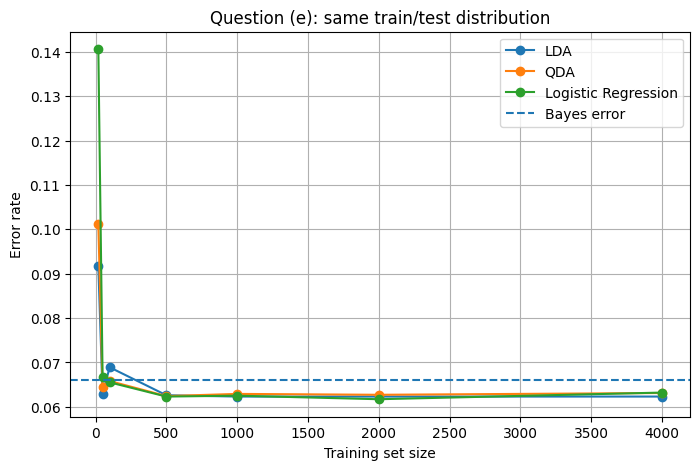

In [12]:
train_sizes=[20, 50, 100, 500, 1000, 2000, 4000]
results_e = compare_classifiers(
    train_sizes=train_sizes,
    train_epsilon=2,
    train_p=0.3,
    test_epsilon=2,
    test_p=0.3,
    test_size=10000
)

plot_error_curves(results_e, bayes_error=0.0661, title="Question (e): same train/test distribution")

As the training size increases, all classifiers converge to a stable error.

QDA achieves the lowest asymptotic error and is closest to the Bayes error, since it matches the true data-generating model.

LDA and logistic regression perform similarly and slightly worse asymptotically, due to their linear decision boundary. However, since the covariance matrices are very close, the true boundary is nearly linear, explaining their strong performance.

For small sample sizes, QDA performs worse due to higher variance, while LDA benefits from stronger assumptions.


To demonstrate that LDA performs well primarily because the covariance matrices of the two classes are similar, we conduct an additional experiment in which the covariance structures are made significantly different.


Summary of results:

Train Size |      LDA |      QDA |   LogReg
--------------------------------------------
        20 |   0.2442 |   0.1319 |   0.2776
        50 |   0.1275 |   0.0738 |   0.1367
       100 |   0.1186 |   0.0742 |   0.1166
       500 |   0.1110 |   0.0740 |   0.1155
      1000 |   0.1141 |   0.0726 |   0.1202
      2000 |   0.1116 |   0.0732 |   0.1173
      4000 |   0.1126 |   0.0726 |   0.1194


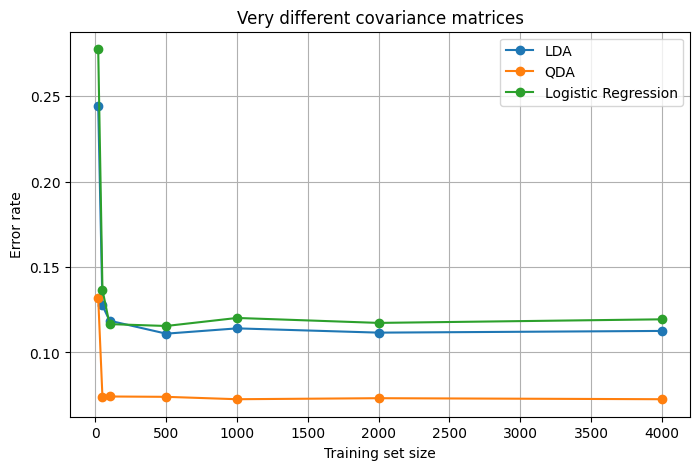

In [13]:
cov0_far = np.array([[1.5, 0.0],
                     [0.0, 1.5]])

cov1_far = np.array([[0.2, 0.0],
                     [0.0, 0.2]])



results_far = compare_classifiers(
    train_sizes=train_sizes,
    train_epsilon=2,
    train_p=0.3,
    test_epsilon=2,
    test_p=0.3,
    test_size=10000,
    train_cov0=cov0_far,
    train_cov1=cov1_far,
    test_cov0=cov0_far,
    test_cov1=cov1_far
)
plot_error_curves(results_far, title="Very different covariance matrices")

In this setting, QDA clearly outperforms both LDA and logistic regression. While QDA reaches an error rate around $0.073$, LDA and logistic regression remain around $0.11$ to $0.12$. This confirms that LDA performed well in the original setting mainly because the covariance matrices were similar, making the optimal decision boundary close to linear. When the covariance matrices become very different, the equal-covariance assumption of LDA is no longer appropriate, and QDA becomes clearly superior.

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [14]:
results_f = compare_classifiers(
    train_sizes=[50],   # because question (f) says use the same classifiers trained in (e)
    train_epsilon=2,
    train_p=0.3,
    test_epsilon=0.5,
    test_p=0.7,
    test_size=1000
)


Summary of results:

Train Size |      LDA |      QDA |   LogReg
--------------------------------------------
        50 |   0.6450 |   0.6420 |   0.6630


Using the same classifiers trained in question (e), we obtain the following test errors on the new test set $\mathcal D'_{\text{test}} = \mathcal D(1000 \mid 0.5, 0.7)$:

- LDA: $0.6450$
- QDA: $0.6420$
- Logistic Regression: $0.6630$

The results are very different from those obtained in question (e). The test errors are now much larger for all classifiers.


This is due to a **distribution shift** between training and test data.

The classifiers were trained on samples from:

$$
\mathcal D_{\text{train}} = \mathcal D(50 \mid 2, 0.3),
$$

but are now tested on:

$$
\mathcal D'_{\text{test}} = \mathcal D(1000 \mid 0.5, 0.7).
$$

Two important changes occur:

1. The separation parameter changes from $\varepsilon = 2$ to $\varepsilon = 0.5$, which makes the classes much closer and therefore much harder to separate.

2. The class prior changes from $p=0.3$ to $p=0.7$, meaning that class 1 becomes the majority class instead of the minority class.

As a result, the classifiers are evaluated on data coming from a different distribution than the one on which they were trained. The decision boundaries learned during training are therefore no longer well adapted to the new test set.

### Conclusion

The strong degradation in performance illustrates the importance of the usual machine learning assumption that training and test data should follow the same distribution. When this assumption is violated, even well-trained classifiers can perform very poorly.

To elaborate further we do the following experiment on a larger set of training sizes.


Summary of results:

Train Size |      LDA |      QDA |   LogReg
--------------------------------------------
        20 |   0.6730 |   0.6730 |   0.6870
        50 |   0.6130 |   0.6090 |   0.6470
       100 |   0.5950 |   0.6020 |   0.6100
       500 |   0.6020 |   0.6070 |   0.6030
      1000 |   0.6070 |   0.6090 |   0.6090
      2000 |   0.6030 |   0.6100 |   0.6110
      4000 |   0.6050 |   0.6110 |   0.6130


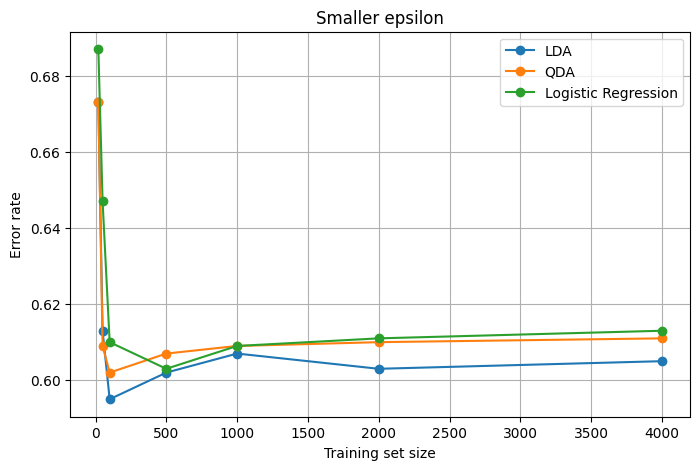

In [15]:
results_f_detailed = compare_classifiers(
    train_sizes=train_sizes,   # because question (f) says use the same classifiers trained in (e)
    train_epsilon=2,
    train_p=0.3,
    test_epsilon=0.5,
    test_p=0.7,
    test_size=1000
)
plot_error_curves(results_f_detailed, title="Smaller epsilon")

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

Manual features
- **FamilySize** : ***SibSp + Parch + 1*** : Solo travellers and very large families had lower survival
- **IsAlone** : ***FamilySize == 1*** : Binary flag isolating the solo-traveller effect
- **IsFemale** : ***Sex*** : Strongest single predictor — "women first" evacuation
- **AgeMissing** : ***Age.isna()*** : Missingness in Age can be informative
- **Age** : ***Agefillna(median)*** : Fills nulls with median
- **FarePerPerson** : **Fare / FamilySize*** : Raw Fare is inflated for group tickets 
- **Deck** : ***First letter of Cabin*** : Proxies physical location on the ship
- **Title** : ***Name (regex)*** Encodes age+gender combinations more finely than raw columns: Master = young boy, Miss = unmarried female, etc. Rare titles grouped to avoid overfitting on sparse values
- **Rare title grouping** : ***Title*** : Titles appearing once or twice
- **TicketPrefix** : ***Alphabetic prefix of Ticket*** : Correlates with embarkation point and fare class
- **FemaleAnd1stClass** : ***IsFemale & Pclass==1*** : First-class women had near-100% survival

**Encoding with skrub.TableVectorizer**

- **Pclass, IsFemale, IsAlone, FamilySize, Age, Fare, FarePerPerson, AgeMissing, FemaleAnd1stClass** : Numeric, Passed through, Already numeric; HGBC needs no scaling
- **Sex, Embarked, Deck, Title** : Low-cardinality categorical, OneHotEncoder, Few unique values → lossless, interpretable encoding
- **Name, Ticket, TicketPrefix, Cabin** : High-cardinality string, MinHashEncoder / StringEncoder, Too many unique values for one-hot; hashing/embedding preserves string similarity in a fixed-width dense vector


In [18]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from skrub import TableVectorizer

train = pd.read_csv("titanic/train.csv")
test  = pd.read_csv("titanic/test.csv")

def feature_engineering(df):
    df = df.copy()
    # Family
    df["FamilySize"]    = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"]       = (df["FamilySize"] == 1).astype(int)
    # Gender
    df["IsFemale"]      = (df["Sex"] == "female").astype(int)
    # Age
    df["AgeMissing"]    = df["Age"].isna().astype(int)
    df["Age"]           = df["Age"].fillna(df["Age"].median())
    # Fare per person (KEY fix)
    df["FarePerPerson"] = df["Fare"].fillna(df["Fare"].median()) / df["FamilySize"]
    # Cabin → Deck (better than binary HasCabin)
    df["Deck"]          = df["Cabin"].str[0].fillna("Unknown")
    # Title with rare grouping
    df["Title"]         = df["Name"].str.extract(r", (\w+)\.", expand=False)
    rare = ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona","Mlle","Ms","Mme"]
    df["Title"]         = df["Title"].replace(rare, "Rare")
    # Ticket prefix
    df["TicketPrefix"]  = df["Ticket"].str.extract(r"^([A-Za-z./]+)", expand=False).fillna("None")
    # One interaction
    df["FemaleAnd1stClass"] = ((df["IsFemale"] == 1) & (df["Pclass"] == 1)).astype(int)
    return df

train = feature_engineering(train)
test  = feature_engineering(test)

y      = train["Survived"]
X      = train.drop(columns=["Survived"])
X_test = test[X.columns]

clf = Pipeline([
    ("preprocess", TableVectorizer()),   # SimpleImputer removed — HGBC handles NaNs natively
    ("model", HistGradientBoostingClassifier(random_state=0)),
])

param_dist = {
    "model__max_depth":         [3, 4, 5, 6, None],
    "model__learning_rate":     [0.01, 0.03, 0.05, 0.1],
    "model__max_iter":          [200, 300, 500],
    "model__min_samples_leaf":  [10, 20, 30],
    "model__l2_regularization": [0.0, 0.1, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

search = RandomizedSearchCV(
    clf, param_dist,
    n_iter=40, cv=cv,
    scoring="accuracy",
    random_state=0, n_jobs=-1, verbose=1,
)
search.fit(X, y)
print("Best params:", search.best_params_)
print("Best CV:    ", search.best_score_)

preds = search.best_estimator_.predict(X_test)

pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": preds
}).to_csv("submission.csv", index=False)
print("Saved submission.csv")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'model__min_samples_leaf': 10, 'model__max_iter': 200, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__l2_regularization': 0.0}
Best CV:     0.8451133011110414
Saved submission.csv


**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

Classifier: **HistGradientBoostingClassifier** with **RandomizedSearchCV**

A single model was used after comparing multiple classifiers. The choice of HistGradientBoostingClassifier was motivated by:

- Native NaN handling : no imputation step needed; the algorithm learns at each split whether to send missing values left or right
- Native categorical support : works directly with TableVectorizer's ToCategorical output on low-cardinality columns
- Strong performance on small tabular datasets : gradient boosting consistently dominates benchmarks at this scale (~900 training rows)
- Invariance to feature scale : no standardisation needed, keeping the pipeline simple
- Fast training : histogram binning makes it much faster than standard GradientBoostingClassifier, enabling a RandomizedSearchCV over 40 configurations to run in reasonable time

The public score we got from Kaggle was : 0.811